# No-Build Modal Matrices and the LRT Market — 2040 / 2050

Steps 5–6 of the forecast hierarchy. Modes are **not** grown independently —
that would freeze modal shares into the growth and leave nothing for the LRT to
change. Instead:

1. total trips were forecast first (`Forecast_matrices_2040_2050.ipynb`);
2. the **no-LRT future modal split** is a pivot of the smoothed base shares onto
   the new totals:
   $$T^{m,without}_{ij,y} = T^{ALL}_{ij,y} \cdot \tilde S^{m,2022}_{ij}$$
3. the LRT is introduced afterwards, reallocating trips within an explicitly
   defined market (this notebook defines the market; the capture model follows).

The pivot freezes behavior only at the **cell** level. Aggregate modal shares
still move, because the scenarios redistribute demand across cells with very
different transit shares — a pure composition effect, measured below. Behavioral
trends (congestion growth, parking cost, heavy-rail improvements, bus network
changes, car-ownership change) are deliberate scenario levers **on top of** this
reference, not defaults; none are applied here.

**LRT market.** $M^{LRT}_{ij} = 1$ where the OD pair can plausibly use the line.
At the 25-area resolution the corridor areas are the station-catchment band of
the single connected alignment (Tirat Carmel – Haifa core – Krayot / Kiryat Ata –
Shefaram – Nazareth), so:

- **core market** — both ends in corridor areas (mixed areas 15, 18 count as
  corridor, as in the share strata): catchment at both ends, one-seat ride,
  route direction along the line;
- **extended market** — exactly one end in a corridor area: reachable with
  feeder/egress, counted separately and not in $T^{market}$;
- competitive travel time is deliberately **not** a market gate here — it is
  what the capture model prices per OD pair in the next step. Intra-area cells
  stay in the core market (several corridor areas span multiple stations);
  their low base transit share already carries into capture via the pivot.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 220)
SCEN = ['BU_2040', 'BU_2050', 'HS_2040', 'HS_2050']
MODES = ['car_other', 'bus', 'rail']

def load_area(name):
    m = pd.read_csv(name, index_col=0)
    m.index = m.index.astype(int); m.columns = m.columns.astype(int)
    return m

T_all = {s: load_area(f'Output/forecast/all_modes_area_{s}.csv') for s in SCEN}
S = {m: load_area(f'Output/forecast/share_{m}_2022_smoothed.csv') for m in MODES}
AREAS = list(T_all[SCEN[0]].index)
share_sum = sum(S.values())
assert np.allclose(share_sum.values, 1.0, atol=1e-4)

T22 = load_area('Output/transit/all_adjusted_area_2022.csv')
bus22 = load_area('Output/bus/bus_od_area_new_filtered.csv').reindex(index=AREAS, columns=AREAS, fill_value=0)
rail22 = load_area('Output/train/train_od_area.csv').reindex(index=AREAS, columns=AREAS, fill_value=0) * 54.7 / 69.0

nobuild = {}
for s in SCEN:
    for m in MODES:
        nb_ = T_all[s] * S[m]
        nobuild[(s, m)] = nb_
        nb_.round(2).to_csv(f'Output/forecast/nobuild_{m}_{s}.csv')
    resid = (sum(nobuild[(s, m)] for m in MODES) - T_all[s]).abs().values.max()
    assert resid < 0.5, (s, resid)
print('12 no-build modal matrices written; mode sums reproduce T_ALL per cell '
      f'(max residual < 0.5 trips, share rounding)')

12 no-build modal matrices written; mode sums reproduce T_ALL per cell (max residual < 0.5 trips, share rounding)


## Composition effect — what the pivot does and does not freeze

In [2]:
legend = pd.read_csv('Output/ths2017/study_taz/submatrices/area_legend.csv').set_index('AggAreaCode')
is_corr = legend.IsLRT_Corridor.reindex(AREAS).isin([1, -1]).values
corr_mask = np.outer(is_corr, is_corr)

rows = []
base_transit = (bus22 + rail22).values
rows.append({'scenario': '2022 base', 'trips': T22.values.sum(),
             'transit_share_%': 100 * base_transit.sum() / T22.values.sum(),
             'transit_share_corridor_%': 100 * base_transit[corr_mask].sum() / T22.values[corr_mask].sum()})
for s in SCEN:
    tr = (nobuild[(s, 'bus')] + nobuild[(s, 'rail')]).values
    tot = T_all[s].values
    rows.append({'scenario': s, 'trips': tot.sum(),
                 'transit_share_%': 100 * tr.sum() / tot.sum(),
                 'transit_share_corridor_%': 100 * tr[corr_mask].sum() / tot[corr_mask].sum()})
comp = pd.DataFrame(rows).set_index('scenario')
print(comp.round(2).to_string())
print('\nCell-level shares are identical across scenarios by construction; every '
      'difference above is demand redistribution across cells (composition), not behavior.')

               trips  transit_share_%  transit_share_corridor_%
scenario                                                       
2022 base  276355.16             8.93                      8.98
BU_2040    380288.34             7.50                      6.48
BU_2050    459831.44             7.65                      7.10
HS_2040    384839.57             7.96                      7.64
HS_2050    461083.47             7.91                      7.62

Cell-level shares are identical across scenarios by construction; every difference above is demand redistribution across cells (composition), not behavior.


## LRT market

In [3]:
n_corr_ends = is_corr[:, None].astype(int) + is_corr[None, :].astype(int)
M_core = (n_corr_ends == 2).astype(float)
M_ext = (n_corr_ends == 1).astype(float)
pd.DataFrame(M_core, index=AREAS, columns=AREAS).astype(int)\
  .to_csv('Output/forecast/lrt_market_flag.csv')

rows = []
for s in SCEN:
    tot = T_all[s].values
    core, ext = (tot * M_core).sum(), (tot * M_ext).sum()
    (T_all[s] * M_core).round(2).to_csv(f'Output/forecast/lrt_market_{s}.csv')
    rows.append({'scenario': s, 'total_trips': tot.sum(), 'core_market': core,
                 'core_%': 100 * core / tot.sum(), 'extended_market': ext,
                 'ext_%': 100 * ext / tot.sum(),
                 'core_transit_nobuild': ((nobuild[(s, 'bus')] + nobuild[(s, 'rail')]).values * M_core).sum()})
mkt = pd.DataFrame(rows).set_index('scenario')
mkt.round(1).to_csv('Output/forecast/lrt_market_summary.csv')
print(mkt.round(1).to_string())

top = (T_all['HS_2050'] * M_core).stack()
top = top[top.index.get_level_values(0) != top.index.get_level_values(1)].nlargest(10)
names = legend.AggAreaName
print('\nTop inter-area core-market OD pairs, HS 2050:')
for (i, j), v in top.items():
    print(f'  {names[i]:>22} -> {names[j]:<22} {v:8,.0f}')

          total_trips  core_market  core_%  extended_market  ext_%  core_transit_nobuild
scenario                                                                                
BU_2040      380288.3     156910.1    41.3          56957.5   15.0               10172.3
BU_2050      459831.4     200446.4    43.6          61983.9   13.5               14235.7
HS_2040      384839.6     146041.9    37.9          64703.5   16.8               11150.5
HS_2050      461083.5     176751.2    38.3          83308.9   18.1               13474.1

Top inter-area core-market OD pairs, HS 2050:
             TiratCarmel -> Nazareth Area             2,514
               Hamoshava -> Bat Galim                 2,412
               Bat Galim -> Kiryat Eliezer            2,226
          Kiryat Eliezer -> Bat Galim                 1,728
              Lower City -> Nazareth Area             1,698
              Neve David -> Ein Hayam                 1,329
               Ein Hayam -> Hamoshava                 1,274

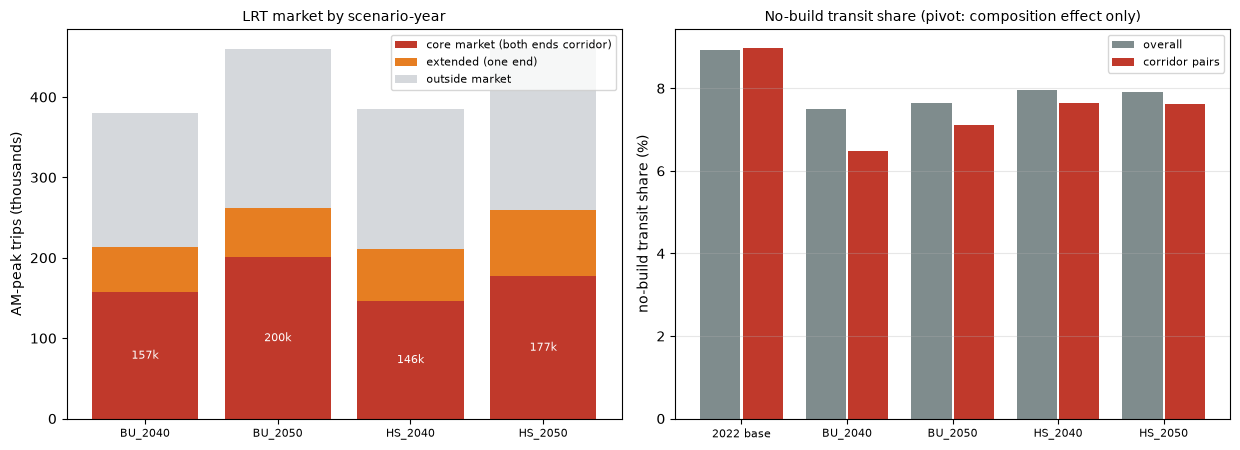

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
x = np.arange(len(SCEN))
core = mkt.core_market / 1000
ext = mkt.extended_market / 1000
rest = mkt.total_trips / 1000 - core - ext
ax.bar(x, core, color='#c0392b', label='core market (both ends corridor)')
ax.bar(x, ext, bottom=core, color='#e67e22', label='extended (one end)')
ax.bar(x, rest, bottom=core + ext, color='#d5d8dc', label='outside market')
for i, s in enumerate(SCEN):
    ax.text(i, core[s] / 2, f"{core[s]:.0f}k", ha='center', va='center', fontsize=8, color='white')
ax.set_xticks(x); ax.set_xticklabels(SCEN, fontsize=8)
ax.set_ylabel('AM-peak trips (thousands)'); ax.set_title('LRT market by scenario-year', fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
labels = ['2022 base'] + SCEN
vals = comp['transit_share_corridor_%'].values
ax.bar(np.arange(len(labels)), comp['transit_share_%'], width=0.38, color='#7f8c8d', label='overall')
ax.bar(np.arange(len(labels)) + 0.4, vals, width=0.38, color='#c0392b', label='corridor pairs')
ax.set_xticks(np.arange(len(labels)) + 0.2); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('no-build transit share (%)')
ax.set_title('No-build transit share (pivot: composition effect only)', fontsize=10)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig('Output/figures/nobuild_lrt_market.png', dpi=150, bbox_inches='tight')
plt.show()

## Outputs

- `Output/forecast/nobuild_{car_other,bus,rail}_{scenario}.csv` — 12 no-build
  modal matrices (pivot of smoothed 2022 shares onto scenario-year totals).
- `Output/forecast/lrt_market_flag.csv` — $M^{LRT}$ (core market, 0/1).
- `Output/forecast/lrt_market_{scenario}.csv` — $T^{market}_{ij,y}$, all-modes
  trips in the core market.
- `Output/forecast/lrt_market_summary.csv` — market sizes per scenario-year.

**Next (final step)**: the capture model — for each core-market OD pair, an LRT
share pivoted off the smoothed no-build shares (e.g. incremental logit on
in-vehicle + access/egress time vs car and existing bus), applied to
$T^{market}$; the extended market enters only through feeder assumptions.